# Seattle and San Francisco Weather Analysis

## Import libraries

In [1]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
# seaborn is a data visualization library built on matplotlib
import seaborn as sns

# set the plotting style
sns.set_style("whitegrid")


# Find the project root so the data paths work after cloning the repository.
cwd = Path.cwd()
candidates = [cwd, cwd / "weather", cwd.parent]
PROJECT_DIR = next(
    path for path in candidates
    if (path / "data" / "seattle_rain.csv").exists()
)
DATA_DIR = PROJECT_DIR / "data"

## Load the data

### Load the Seattle dataset

Read Seattle's daily weather records from the CSV file.

In [2]:
seattle_data = pd.read_csv(DATA_DIR / "seattle_rain.csv")

Read daily precipitation records from San Francisco International Airport.

In [3]:
sf_data = pd.read_csv(DATA_DIR / "sf_rain.csv")

## Explore the datasets

In [4]:
seattle_data.head()
seattle_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1658 entries, 0 to 1657
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1658 non-null   str    
 1   NAME     1658 non-null   str    
 2   DATE     1658 non-null   str    
 3   DAPR     23 non-null     float64
 4   MDPR     23 non-null     float64
 5   PRCP     1636 non-null   float64
 6   SNOW     353 non-null    float64
 7   SNWD     66 non-null     float64
 8   WESD     15 non-null     float64
 9   WESF     28 non-null     float64
dtypes: float64(7), str(3)
memory usage: 194.4 KB


In [5]:
sf_data.info()
sf_data.head()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1826 non-null   str    
 1   NAME     1826 non-null   str    
 2   DATE     1826 non-null   str    
 3   PRCP     1826 non-null   float64
dtypes: float64(1), str(3)
memory usage: 169.5 KB


,STATION,NAME,DATE,PRCP
0,USW00023234,"SAN FRANCISCO INTERNATIONAL AIRPORT, CA US",2018-01-01,0.00
1,USW00023234,"SAN FRANCISCO INTERNATIONAL AIRPORT, CA US",2018-01-02,0.00
2,USW00023234,"SAN FRANCISCO INTERNATIONAL AIRPORT, CA US",2018-01-03,0.30
3,USW00023234,"SAN FRANCISCO INTERNATIONAL AIRPORT, CA US",2018-01-04,0.03
4,USW00023234,"SAN FRANCISCO INTERNATIONAL AIRPORT, CA US",2018-01-05,0.19


In [6]:

seattle_data['STATION'].unique(), seattle_data['STATION'].nunique()

(<ArrowStringArray>
 ['US1WAKG0225']
 Length: 1, dtype: str,
 1)

List Seattle station IDs to verify the source station.

In [7]:
sf_data['STATION'].unique(), sf_data['STATION'].nunique()

(<ArrowStringArray>
 ['USW00023234']
 Length: 1, dtype: str,
 1)

In [8]:
seattle_data.columns

Index(['STATION', 'NAME', 'DATE', 'DAPR', 'MDPR', 'PRCP', 'SNOW', 'SNWD',
       'WESD', 'WESF'],
      dtype='str')

List the columns available in Seattle's dataset.

In [9]:
sf_data.columns

Index(['STATION', 'NAME', 'DATE', 'PRCP'], dtype='str')

List the columns available in San Francisco's dataset.

### Examine the `DATE` column

Display Seattle's date values to inspect their original format.

In [10]:
seattle_data['DATE']

0         1/1/18
1         1/2/18
2         1/3/18
3         1/4/18
4         1/5/18
          ...   
1653    12/27/22
1654    12/28/22
1655    12/29/22
1656    12/30/22
1657    12/31/22
Name: DATE, Length: 1658, dtype: str

Display the San Francisco dates before converting them.

In [11]:
sf_data['DATE']

0       2018-01-01
1       2018-01-02
2       2018-01-03
3       2018-01-04
4       2018-01-05
           ...    
1821    2022-12-27
1822    2022-12-28
1823    2022-12-29
1824    2022-12-30
1825    2022-12-31
Name: DATE, Length: 1826, dtype: str

#### Convert `DATE` to datetime

Convert Seattle dates to datetime so they can be filtered and compared.

In [12]:
seattle_data['DATE'] = pd.to_datetime(seattle_data['DATE'])
seattle_data.head()

/var/folders/91/2nb02qkx7b91txdkwn_nrxf80000gn/T/ipykernel_4153/94368199.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  seattle_data['DATE'] = pd.to_datetime(seattle_data['DATE'])


,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD,WESD,WESF
0,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-01,NaN,NaN,0.00,NaN,NaN,NaN,NaN
1,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-02,NaN,NaN,0.00,NaN,NaN,NaN,NaN
2,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-03,NaN,NaN,0.00,NaN,NaN,NaN,NaN
3,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-04,NaN,NaN,0.00,NaN,NaN,NaN,NaN
4,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-05,NaN,NaN,0.25,NaN,NaN,NaN,NaN


Convert San Francisco dates to datetime and preview the parsed values.

In [13]:
sf_data['DATE'] = pd.to_datetime(sf_data['DATE'])
sf_data['DATE']

0      2018-01-01
1      2018-01-02
2      2018-01-03
3      2018-01-04
4      2018-01-05
          ...    
1821   2022-12-27
1822   2022-12-28
1823   2022-12-29
1824   2022-12-30
1825   2022-12-31
Name: DATE, Length: 1826, dtype: datetime64[us]

### Determine the date range

Find the first and last dates in Seattle's records.

In [14]:
seattle_data['DATE'].agg(['min','max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[us]

Also summarize Seattle's date range as a labeled minimum and maximum.

In [15]:
sf_data['DATE'].agg(['min', 'max'])


min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[us]

## Are the data suitable for answering the question?

### Plot Seattle daily precipitation

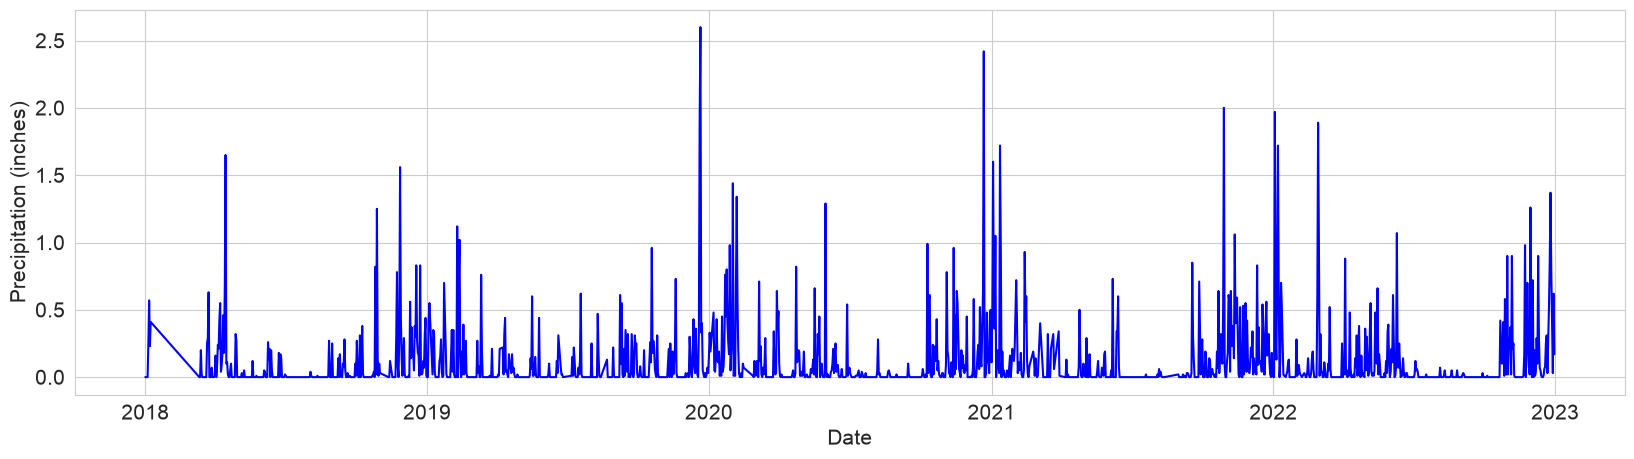

In [16]:
plt.figure(figsize=(20, 5))

sns.lineplot(data=seattle_data, x='DATE', y='PRCP', color='blue')

plt.xlabel('Date', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize=15)

plt.tick_params(labelsize=15)
plt.show()

### Plot San Francisco daily precipitation

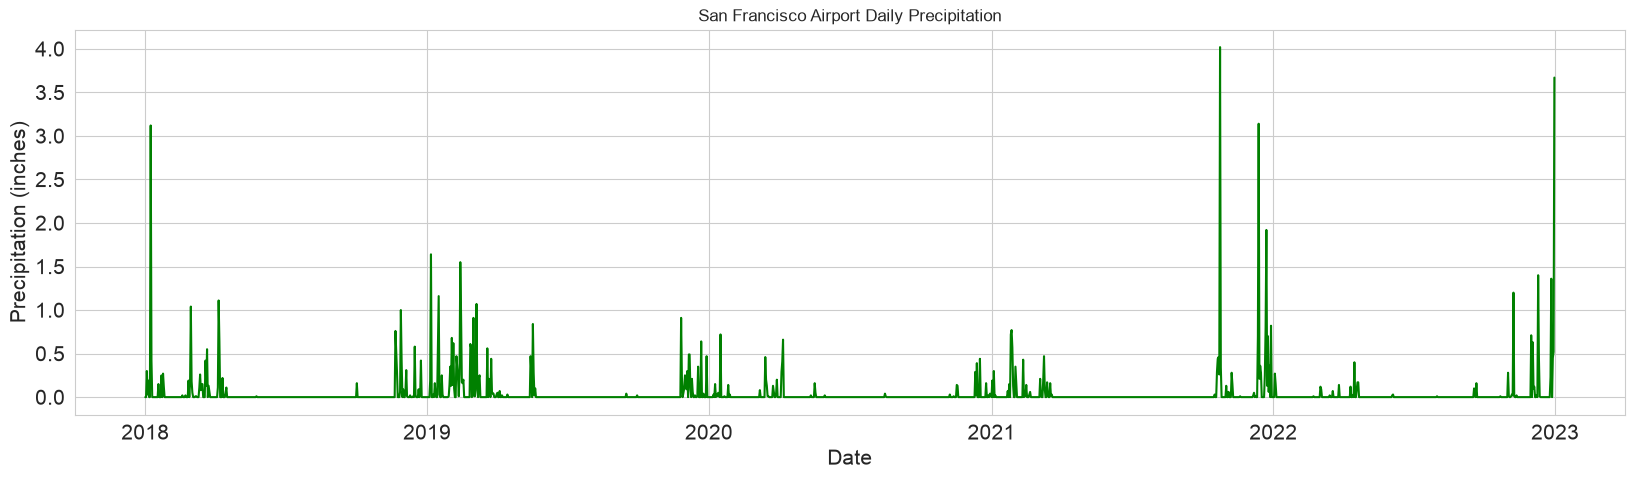

In [17]:
plt.figure(figsize=(20, 5))
sns.lineplot(data=sf_data, x='DATE', y='PRCP', color='green')
plt.xlabel('Date', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize=15)
plt.tick_params(labelsize=15)
plt.title('San Francisco Airport Daily Precipitation')
plt.show()

Select Seattle's precipitation column for focused inspection.

In [18]:
seattle_data['PRCP']

0       0.00
1       0.00
2       0.00
3       0.00
4       0.25
        ... 
1653    0.78
1654    0.40
1655    0.03
1656    0.62
1657    0.17
Name: PRCP, Length: 1658, dtype: float64

In [19]:
sf_data['PRCP']

0       0.00
1       0.00
2       0.30
3       0.03
4       0.19
        ... 
1821    1.36
1822    0.00
1823    0.45
1824    0.52
1825    3.67
Name: PRCP, Length: 1826, dtype: float64

Verify the filtered San Francisco dataset's row and column counts.

## Join data frames keeping `DATE` and `PRCP` columns

Join both stations by date, keeping each station's precipitation in a separate column.

In [20]:
df_merged = sf_data[['DATE', 'PRCP']].merge(
    seattle_data[['DATE', 'PRCP']],
    on='DATE',
    how='outer',
    suffixes=('_SF', '_SEA')
)

Preview the joined table and confirm the station columns line up by date.

In [21]:
df_merged.head()

,DATE,PRCP_SF,PRCP_SEA
0,2018-01-01,0.00,0.00
1,2018-01-02,0.00,0.00
2,2018-01-03,0.30,0.00
3,2018-01-04,0.03,0.00
4,2018-01-05,0.19,0.25


### Create a tidy data frame with columns for city and precipitation

Reshape the joined columns into one row per date and station.

In [22]:
df = pd.melt(
    df_merged,
    id_vars=['DATE'],
    value_vars=['PRCP_SF', 'PRCP_SEA'],
    var_name='City',
    value_name='Precipitation'
)

Preview the reshaped date, station, and precipitation columns.

How did this change the DataFrame?

In [23]:
df.head()

,DATE,City,Precipitation
0,2018-01-01,PRCP_SF,0.00
1,2018-01-02,PRCP_SF,0.00
2,2018-01-03,PRCP_SF,0.30
3,2018-01-04,PRCP_SF,0.03
4,2018-01-05,PRCP_SF,0.19


Rename the city values 'STL' and 'SEA'

#### Rename columns to lowercase with `df.rename()`

In [24]:
df.loc[df['City'] == 'PRCP_SF', 'City'] = 'SF'
df.loc[df['City'] == 'PRCP_SEA', 'City'] = 'SEA'

Assign a short city label to each station's precipitation rows.

In [25]:
df.head()

,DATE,City,Precipitation
0,2018-01-01,SF,0.00
1,2018-01-02,SF,0.00
2,2018-01-03,SF,0.30
3,2018-01-04,SF,0.03
4,2018-01-05,SF,0.19


Check that the station labels were updated as intended.

Rename the date column to `Date` for clearer downstream code.

In [26]:
df = df.rename(columns={'DATE': 'Date'})
df

,Date,City,Precipitation
0,2018-01-01,SF,0.00
1,2018-01-02,SF,0.00
2,2018-01-03,SF,0.30
3,2018-01-04,SF,0.03
4,2018-01-05,SF,0.19
...,...,...,...
3647,2022-12-27,SEA,0.78
3648,2022-12-28,SEA,0.40
3649,2022-12-29,SEA,0.03
3650,2022-12-30,SEA,0.62


## Identify and fill in missing values

Summarize the data types and non-null values in the reshaped table.

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           3652 non-null   datetime64[us]
 1   City           3652 non-null   str           
 2   Precipitation  3462 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 94.6 KB


In [28]:
df.notna().sum()

Date             3652
City             3652
Precipitation    3462
dtype: int64

Count non-missing values in each column.

In [29]:
df.isna().sum()

Date               0
City               0
Precipitation    190
dtype: int64

Count missing Seattle precipitation values after the datasets are reshaped.

In [30]:
df.loc[df['City'] == 'SEA', 'Precipitation'].isna().sum()

np.int64(190)

Count missing San Francisco precipitation values for comparison.

In [31]:
df.loc[df['City'] == 'SF', 'Precipitation'].isna().sum()

np.int64(0)

Impute missing values

We will replace missing values with the mean across years of values on that day.



In [32]:
df['day_of_year'] = pd.DatetimeIndex(df['Date']).dayofyear

Preview the added seasonal date column.

In [33]:
df.head()

,Date,City,Precipitation,day_of_year
0,2018-01-01,SF,0.00,1
1,2018-01-02,SF,0.00,2
2,2018-01-03,SF,0.30,3
3,2018-01-04,SF,0.03,4
4,2018-01-05,SF,0.19,5


In [34]:
mean_day_precipitation=df.loc[
    df['City']=='SEA',
    ['Precipitation','day_of_year']
].groupby(
    'day_of_year'
).mean()
mean_day_precipitation

,Precipitation
day_of_year,
1,0.052000
2,0.150000
3,0.836000
4,0.370000
5,0.246667
...,...
362,0.120000
363,0.102000
364,0.268000


In [35]:
df.head()

,Date,City,Precipitation,day_of_year
0,2018-01-01,SF,0.00,1
1,2018-01-02,SF,0.00,2
2,2018-01-03,SF,0.30,3
3,2018-01-04,SF,0.03,4
4,2018-01-05,SF,0.19,5


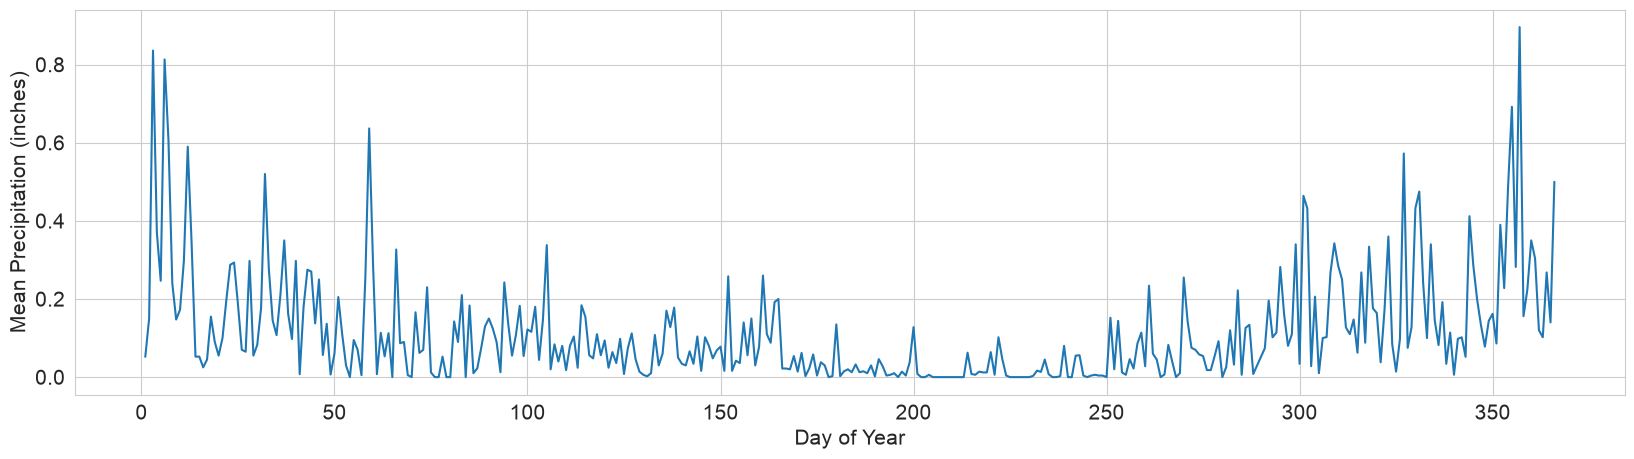

In [36]:
plt.figure(figsize=(20,5))
sns.lineplot(data=mean_day_precipitation, x='day_of_year', y='Precipitation')
plt.xlabel('Day of Year', fontsize=15)
plt.ylabel('Mean Precipitation (inches)', fontsize=15)
plt.tick_params(labelsize=15)   
plt.show()

In [37]:
indices = np.where(df['Precipitation'].isna() == True)[0]
indices

array([1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844,
       1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855,
       1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866,
       1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877,
       1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888,
       1889, 1890, 1891, 1892, 1893, 1894, 1895, 2090, 2131, 2132, 2133,
       2134, 2135, 2136, 2137, 2138, 2139, 2140, 2195, 2196, 2197, 2214,
       2215, 2244, 2245, 2246, 2247, 2248, 2249, 2286, 2287, 2288, 2362,
       2363, 2368, 2369, 2370, 2371, 2372, 2373, 2374, 2375, 2376, 2377,
       2417, 2418, 2419, 2420, 2421, 2422, 2423, 2517, 2518, 2519, 2520,
       2521, 2522, 2523, 2524, 2559, 2560, 2561, 2602, 2603, 2604, 2605,
       2606, 2607, 2608, 2609, 2610, 2611, 2612, 2818, 2819, 2820, 2821,
       2822, 2823, 2824, 2825, 2826, 2827, 2972, 2973, 2974, 2975, 2983,
       2984, 2986, 2987, 2988, 3000, 3001, 3004, 30

In [38]:
for index in indices:
    df.loc[index,'Precipitation'] = mean_day_precipitation.loc[df.loc[index, 'day_of_year']].values[0]

In [39]:
df.isna().sum()

Date             0
City             0
Precipitation    0
day_of_year      0
dtype: int64

## Export the clean .csv file

In [ ]:
df.to_csv(DATA_DIR / "clean_seattle_sf_weather.csv", encoding="utf-8-sig", index=False)

Plot the cleaned csv to visualise the precipitations throughout the year

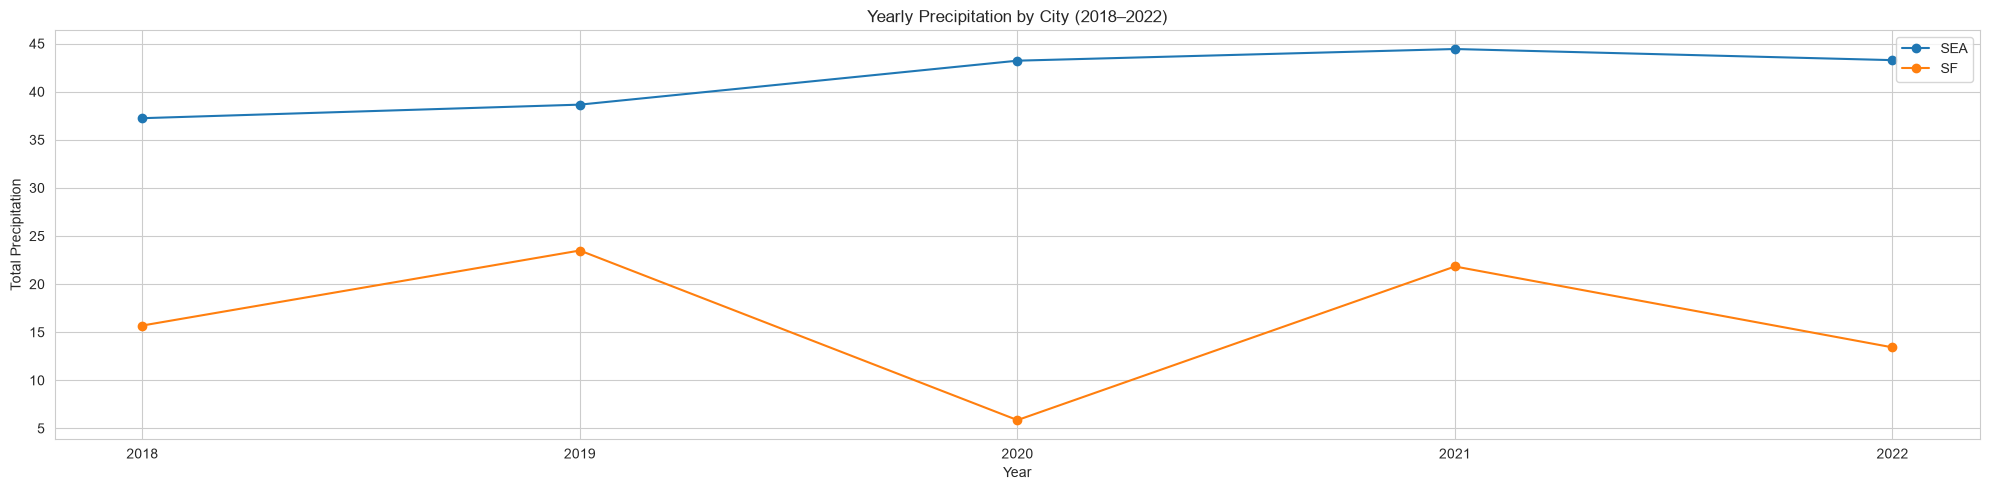

In [41]:

plt.figure(figsize=(20,5))

df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

yearly_rain = (
    df.groupby(["Year", "City"])["Precipitation"]
      .sum()
      .reset_index()
)

for city in yearly_rain["City"].unique():
    city_data = yearly_rain[yearly_rain["City"] == city]
    plt.plot(
        city_data["Year"],
        city_data["Precipitation"],
        marker="o",
        label=city
    )

plt.title("Yearly Precipitation by City (2018–2022)")
plt.xlabel("Year")
plt.ylabel("Total Precipitation")
plt.xticks(range(2018, 2023))
plt.legend()
plt.tight_layout()
plt.show()

Plot the cleaned csv to visualise the precipitations throughout the year Monthly

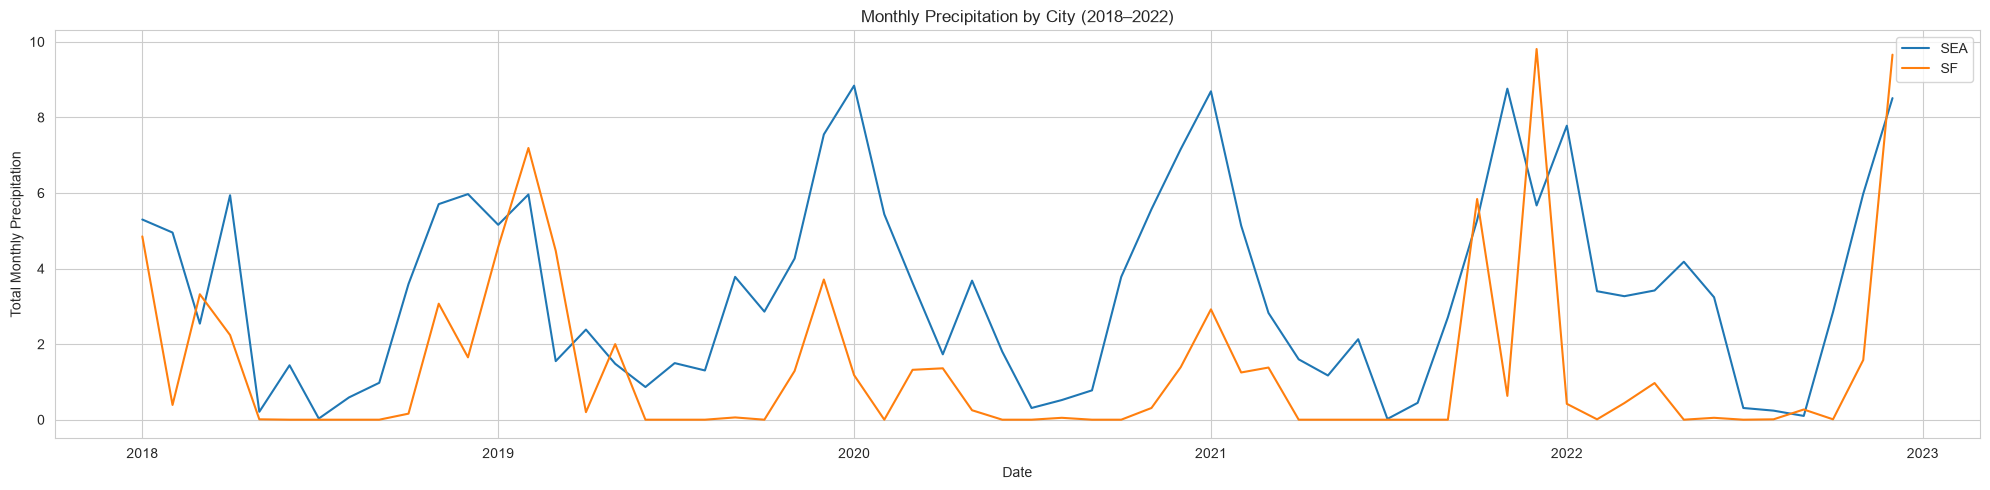

In [42]:
df["Month"] = df["Date"].dt.to_period("M")
plt.figure(figsize=(20,5))
monthly_rain = (
    df.groupby(["Month", "City"])["Precipitation"]
      .sum()
      .reset_index()
)

monthly_rain["Month"] = monthly_rain["Month"].dt.to_timestamp()

for city in monthly_rain["City"].unique():
    city_data = monthly_rain[monthly_rain["City"] == city]

    plt.plot(
        city_data["Month"],
        city_data["Precipitation"],
        label=city
    )

plt.title("Monthly Precipitation by City (2018–2022)")
plt.xlabel("Date")
plt.ylabel("Total Monthly Precipitation")
plt.legend()
plt.tight_layout()
plt.show()

### Conclusion

From 2018 to 2022, precipitation varied month to month in both cities, and San Francisco recorded more precipitation in some months. However, the yearly totals indicate that Seattle recorded more precipitation overall in this dataset. 